In [162]:
import FIRM.base.operators.implications as implications
import FIRM.base.operators.tnorms as tnorms
import FIRM.base.fuzzy_data as fuzzy_data
from FIRM.methods.AARFI import AARFI_F
import numpy as np
import csv
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

def _attach_tokens_for_pruning(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    out['ant_tokens'] = out['antecedents'].apply(_tokens_from_group)
    out['con_token'] = out['consequents'].apply(lambda c: (_tokens_from_group(c)[0] if _tokens_from_group(c) else ''))
    return out

def prune_redundant_df(df: pd.DataFrame, epsilon: float) -> pd.DataFrame:
    if df.empty:
        return df
    groups = []
    for _, group in df.groupby('con_token', sort=False):
        group_sorted = group.sort_values('n_antecedents', kind='mergesort')
        kept_idx = []
        kept_ants = []
        kept_conf = []
        for idx, row in group_sorted.iterrows():
            A1 = set(row['ant_tokens'])
            c1 = float(row['confidence'])
            redundant = False
            for A2, c2 in zip(kept_ants, kept_conf):
                if A2.issubset(A1) and abs(c1 - c2) < epsilon:
                    redundant = True
                    break
            if not redundant:
                kept_idx.append(idx)
                kept_ants.append(A1)
                kept_conf.append(c1)
        groups.append(group_sorted.loc[kept_idx])
    return pd.concat(groups, ignore_index=True) if groups else df.iloc[0:0]

def _mean_or_nan(xs):
    return float(np.mean(xs)) if xs else np.nan

def _normalized_abs_diff(x: float, y: float, eps: float = 1e-12) -> float:
    return abs(x - y) / (x + y + eps)

def _reverse_asymmetry_fuzzy(measures_df: pd.DataFrame):
    if measures_df is None or measures_df.empty:
        return np.nan, np.nan

    directed = {}
    for _, r in measures_df.iterrows():
        lr = r.get('lrule')
        if lr is None or len(lr) != 2:
            continue
        a = tuple(lr[0])
        b = tuple(lr[1])
        if a == b:
            continue

        conf = float(r.get('confidence', np.nan))
        supp = float(r.get('support', np.nan))
        if not np.isfinite(conf) or not np.isfinite(supp):
            continue

        key = (a, b)
        prev = directed.get(key)
        if prev is None or conf > prev[0]:
            directed[key] = (conf, supp)

    conf_deltas = []
    supp_deltas = []
    seen = set()
    for (a, b), (conf_ab, supp_ab) in directed.items():
        undirected = tuple(sorted((a, b)))
        if undirected in seen:
            continue
        rev = directed.get((b, a))
        if rev is None:
            continue
        conf_ba, supp_ba = rev

        conf_deltas.append(_normalized_abs_diff(conf_ab, conf_ba))
        supp_deltas.append(_normalized_abs_diff(supp_ab, supp_ba))
        seen.add(undirected)

    return _mean_or_nan(conf_deltas), _mean_or_nan(supp_deltas)

def _reverse_asymmetry_crisp(df_rules: pd.DataFrame):
    if df_rules is None or df_rules.empty:
        return np.nan, np.nan

    directed = {}
    for _, r in df_rules.iterrows():
        ants = r.get('ant_tokens')
        con = r.get('con_token')
        if not ants or len(ants) != 1 or not con:
            continue

        a = ants[0]
        b = con
        if a == b:
            continue

        conf = float(r.get('confidence', np.nan))
        supp = float(r.get('support', np.nan))
        if not np.isfinite(conf) or not np.isfinite(supp):
            continue

        key = (a, b)
        prev = directed.get(key)
        if prev is None or conf > prev[0]:
            directed[key] = (conf, supp)

    conf_deltas = []
    supp_deltas = []
    seen = set()
    for (a, b), (conf_ab, supp_ab) in directed.items():
        undirected = tuple(sorted((a, b)))
        if undirected in seen:
            continue
        rev = directed.get((b, a))
        if rev is None:
            continue
        conf_ba, supp_ba = rev

        conf_deltas.append(_normalized_abs_diff(conf_ab, conf_ba))
        supp_deltas.append(_normalized_abs_diff(supp_ab, supp_ba))
        seen.add(undirected)

    return _mean_or_nan(conf_deltas), _mean_or_nan(supp_deltas)

import FIRM.base.ct_fuzzy_rule as fuzzy_rule
import math
from FIRM.base.ct_set_fuzzy_rules import SetFuzzyRules


In [163]:
def _tokens_from_group(group):
    """Return a list of 'Var_Label' tokens from frozenset/set/list/tuple or string."""
    if group is None or (isinstance(group, float) and math.isnan(group)):
        return []
    if isinstance(group, (set, frozenset, list, tuple)):
        return [str(x).strip() for x in group if str(x).strip()]
    if isinstance(group, str):
        s = group.strip()
        if not s:
            return []
        if s.startswith("(") and s.endswith(")"):
            s = s[1:-1].strip()
        return [t.strip() for t in s.split(",")] if "," in s else [s]
    return [str(group).strip()]


def _build_var_and_label_maps(dataset_columns, fuzzy_dataset):
    """
    Returns:
      var_to_idx: {var_name -> position i}
      label_maps: {var_name -> {label_string -> label_index}}
    Labels come from fuzzy_dataset.fv_list[i].get_labels()
    """
    cols_list = list(dataset_columns.tolist()) if hasattr(dataset_columns, "tolist") else list(dataset_columns)
    var_to_idx = {name: i for i, name in enumerate(cols_list)}

    label_maps = {}
    for var_name, i in var_to_idx.items():
        # CALL the method to get the actual label list
        labels = list(fuzzy_dataset.fv_list[i].get_labels)
        # keep original strings; also add a case-insensitive shim
        per_var = {str(lab): j for j, lab in enumerate(labels)}
        label_maps[var_name] = per_var
    return var_to_idx, label_maps


def _resolve_label_idx(var: str, lab: str, label_maps: dict) -> int:
    """
    Map a label string to its index using label_maps[var].
    Tries exact, then case-insensitive exact, then first-letter (if unique).
    """
    per_var = label_maps[var]
    if lab in per_var:
        return per_var[lab]
    # case-insensitive exact
    for k in per_var.keys():
        if k.lower() == lab.lower():
            return per_var[k]
    # First-letter fallback, only if unique
    fl = lab[:1].lower()
    candidates = [name for name in per_var.keys() if name[:1].lower() == fl]
    if len(candidates) == 1:
        return per_var[candidates[0]]
    raise KeyError(f"Unknown label {lab!r} for variable {var!r}. Known labels: {list(per_var.keys())}")


def _pair_from_token(token: str, var_to_idx: dict, label_maps: dict) -> tuple[int, int]:
    """Map 'Var_Label' -> (var_idx, label_idx) using dataset column order + fuzzy_dataset labels."""
    if "_" not in token:
        raise ValueError(f"Expected 'Var_Label', got: {token!r}")
    var, lab = token.rsplit("_", 1)  # last underscore splits var from label
    var = var.strip()
    lab = lab.strip()
    if var not in var_to_idx:
        raise KeyError(f"Variable {var!r} not found in dataset columns: {list(var_to_idx.keys())}")
    var_idx = var_to_idx[var]
    lab_idx = _resolve_label_idx(var, lab, label_maps)
    return (var_idx, lab_idx)


def _group_to_pairs(group, var_to_idx, label_maps):
    tokens = _tokens_from_group(group)
    pairs = [_pair_from_token(t, var_to_idx, label_maps) for t in tokens]
    # Deterministic order (since sets/frozensets are unordered)
    pairs.sort(key=lambda x: x[0])
    return pairs


def _pick_consequent(con_pairs):
    """
    Choose one consequent tuple from con_pairs.
    - If exactly one, use it.
    - If multiple, pick the one with the highest variable index (you can change to lowest).
    """
    if not con_pairs:
        raise ValueError("Rule has no consequent.")
    if len(con_pairs) == 1:
        return con_pairs[0]
    # pick by highest var index (change to min if you prefer)
    return max(con_pairs, key=lambda x: x[0])


def df_to_crfuzzyrules(df: pd.DataFrame, dataset_columns, fuzzy_dataset):
    """
    Build CRFuzzyRule objects from df['antecedents'] and df['consequents'].
    Each CRFuzzyRule receives [*antecedents, consequent] (consequent appended last).
    Returns (rules, consequents_as_singleton_lists) to keep backward compatibility.
    """
    var_to_idx, label_maps = _build_var_and_label_maps(dataset_columns, fuzzy_dataset)

    rules, consequents = [], []
    for _, row in df.iterrows():
        ant_pairs = _group_to_pairs(row["antecedents"], var_to_idx, label_maps)
        con_pairs = _group_to_pairs(row["consequents"], var_to_idx, label_maps)
        c = _pick_consequent(con_pairs)
        combined = ant_pairs + [c]  # consequent at the end
        rules.append(fuzzy_rule.CRFuzzyRule(combined))
        consequents.append([c])  # keep a reference to the chosen consequent
    return rules, consequents

In [164]:
p_ss = -10.0   # Schweizer-Sklar parameter (OP2)
p_ip = 0.01    # exponent for I_p / x*y^p (OP3)

impl_operators = [
    implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.IGNORE),
    implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.LUKASIEWICZ),
    lambda x, y: implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.KSS)(x, y, float(p_ss)),
    lambda x, y: 1 - x + x * np.power(y, p_ip),
]

tnorms_operators = [
    tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.PRODUCT),
    tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.LUKASIEWICZ),
    lambda x, y: tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.SCHWEIZER_SKLAR)(x, y, float(p_ss)),
    lambda x, y: np.maximum(x + y - 1, 0),
]


def F2_ss_kss(x, y, lam=p_ss):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x, y = np.broadcast_arrays(x, y)
    out = np.zeros_like(x, dtype=np.float64)

    m = (x > 0.0) & (y > 0.0)
    if np.any(m):
        xp = x[m]
        yp = y[m]

        with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
            yp_l = np.power(yp, lam)
            cond = np.log(xp) <= (yp_l - 1.0) / lam
            inner = np.power(xp, lam) + yp_l - 1.0 - lam * np.log(xp)
            val = np.power(np.maximum(inner, 0.0), 1.0 / lam)

        out[m] = np.where(cond, xp, val)

    return out


F_operators = [
    lambda x, y: x * y,
    lambda x, y: np.minimum(x, y),
    lambda x, y: F2_ss_kss(x, y, float(p_ss)),
    lambda x, y: x * np.power(y, p_ip),
]



In [165]:
def process_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Integer dtypes -> float64
    - For object/string/categorical columns:
        * If unique non-null values <= 15: keep as object
        * If unique non-null values > 15: keep top 15, others -> "Unknown"
    - Other dtypes left unchanged
    """
    out = df.copy()

    for col in out.columns:
        s = out[col]

        # 1) Integers -> float64
        if pd.api.types.is_integer_dtype(s):
            out[col] = s.astype("float64")
            continue

        # 2) Non-numeric categoricals/strings
        is_cat_like = (
            pd.api.types.is_object_dtype(s)
            or isinstance(s.dtype, pd.CategoricalDtype)
            or pd.api.types.is_string_dtype(s)
        )
        if is_cat_like:
            n_unique = s.nunique(dropna=True)
            if n_unique > 10:
                top15 = s.value_counts(dropna=True).index[:10]
                out[col] = s.where(s.isna() | s.isin(top15), "Unknown").astype("object")
            else:
                out[col] = s.astype("object")

    return out



In [166]:
# 'online_news.csv','global_house.csv'
datasets = ['iris.csv','wdbc.csv','vehicle.csv','abalone.csv','magic.csv']
PRUNE_EPS = 0.05


In [167]:
import csv
import numpy as np
import pandas as pd
import time
from mlxtend.frequent_patterns import apriori, association_rules


n_datasets = len(datasets)
n_operators = len(impl_operators)

# results[op_idx][dat_idx] -> list of CRFuzzyRule (last op_idx = crisp)
results = [[[] for _ in range(n_datasets)] for _ in range(n_operators + 1)]

with open('results.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Operator', 'Dataset', 'Num Rules', 'Coverage', 'Support', 'Confidence', 'ExecTimeSec', 'Asym_Conf_Norm', 'Asym_Supp_Norm'])

    # -------- fuzzy operators --------
    for idx_op in range(n_operators):
        print('Operator:', idx_op)
        I = impl_operators[idx_op]
        T = tnorms_operators[idx_op]
        F = F_operators[idx_op]

        for idx_dat in range(n_datasets):
            name_dataset = datasets[idx_dat]
            print('Dataset:', name_dataset)

            dataset = process_df(pd.read_csv('../assets/' + name_dataset, sep=','))
            # ints -> float
            int_cols = dataset.select_dtypes(include=['int']).columns
            if len(int_cols):
                dataset[int_cols] = dataset[int_cols].astype(float)

            # NOTE: first arg is the shape specifier
            fuzzy_dataset = fuzzy_data.FuzzyDataQuantiles(name_dataset, dataset, 3, ['L', 'M', 'H'])

            t0 = time.perf_counter()
            rules, measures = AARFI_F(dataset, fuzzy_dataset, F=F, T=T, I=I,
                                      min_cov=0.2, min_supp=0.2, min_conf=0.7,
                                      prune_epsilon=PRUNE_EPS,
                                      max_feat=3, verbose=True)
            exec_time = time.perf_counter() - t0

            num_rules = int(len(measures['n_antecedents']))
            coverage = float(np.mean(measures['coverage'])) if num_rules else np.nan
            support = float(np.mean(measures['support'])) if num_rules else np.nan
            confidence = float(np.mean(measures['confidence'])) if num_rules else np.nan
            asym_conf_norm, asym_supp_norm = _reverse_asymmetry_fuzzy(measures)

            print('  num rules:', num_rules)
            print('  coverage :', coverage)
            print('  support  :', support)
            print('  confidence:', confidence)

            writer.writerow([
                f'OP{idx_op}',
                name_dataset,
                num_rules,
                coverage,
                support,
                confidence,
                exec_time,
                asym_conf_norm,
                asym_supp_norm,
            ])

            results[idx_op][idx_dat] = rules.rule_list

    # -------- crisp case --------
    print('Crisp Case ----')
    for idx_dat in range(n_datasets):
        name_dataset = datasets[idx_dat]
        print('Dataset:', name_dataset)

        dataset = process_df(pd.read_csv('../assets/' + name_dataset, sep=','))
        int_cols = dataset.select_dtypes(include=['int']).columns
        if len(int_cols):
            dataset[int_cols] = dataset[int_cols].astype(float)

        fuzzy_dataset = fuzzy_data.FuzzyDataQuantiles(name_dataset, dataset, 3, ['L', 'M', 'H'])

        t0 = time.perf_counter()
        data = dataset.copy()
        for i in range(len(fuzzy_dataset.fv_list)):
            data[dataset.columns[i]] = dataset[dataset.columns[i]].map(
                lambda x: fuzzy_dataset.fv_list[i].eval_max_fuzzy_set(x)
            )

        df_encoded = pd.get_dummies(data, columns=data.columns)
        df_freq = apriori(df_encoded, min_support=0.2, use_colnames=True, verbose=1, max_len=4, low_memory=True)
        df_ar = association_rules(df_freq, metric='confidence', min_threshold=0.7)

        df_rules_filtered = df_ar[
            (df_ar['antecedents'].apply(len) <= 3) &
            (df_ar['consequents'].apply(len) <= 1)
        ].reset_index(drop=True)

        if not df_rules_filtered.empty:
            df_rules_filtered = df_rules_filtered.assign(
                n_antecedents=df_rules_filtered['antecedents'].apply(len)
            )
            df_rules_filtered = _attach_tokens_for_pruning(df_rules_filtered)
            df_rules_filtered = prune_redundant_df(df_rules_filtered, PRUNE_EPS)

        rules_sorted = df_rules_filtered.sort_values(by='confidence', ascending=False).reset_index(drop=True)
        num_rules = int(len(rules_sorted))

        coverage = float(rules_sorted['antecedent support'].mean()) if num_rules else np.nan
        support = float(rules_sorted['support'].mean()) if num_rules else np.nan
        confidence = float(rules_sorted['confidence'].mean()) if num_rules else np.nan
        asym_conf_norm, asym_supp_norm = _reverse_asymmetry_crisp(df_rules_filtered)
        exec_time = time.perf_counter() - t0

        print('  num rules:', num_rules)
        print('  coverage :', coverage)
        print('  support  :', support)
        print('  confidence:', confidence)

        writer.writerow([
            'CRISP',
            name_dataset,
            num_rules,
            coverage,
            support,
            confidence,
            exec_time,
            asym_conf_norm,
            asym_supp_norm,
        ])

        dataset_columns = dataset.columns.str.strip()
        rules_crisp, _ = df_to_crfuzzyrules(rules_sorted, dataset_columns, fuzzy_dataset)
        results[n_operators][idx_dat] = rules_crisp

print("Results have been saved to 'results.csv'")


[INFO] AARFI_F (min_cov=0.200, min_supp=0.200, min_conf=0.700, max_feat=3)
[INFO] Precomputing singleton memberships for 150 rows and 5 features...
[INFO] Cached 15 singleton membership vectors.
[INFO] Starting Apriori (min_cov=0.2000, max_feat=3)...
[INFO] Using precomputed singleton memberships (15 vectors).
[INFO] Generated 15 fuzzy 1-itemsets across 5 features (15 total labels).
[INFO] Evaluating 15 candidate itemsets (min_cov=0.2000)...
[INFO] Selected 15 frequent itemsets (100.0% pass rate).
[INFO] Level-1: 15 frequent itemsets.
[INFO] ---- Level 2 ----
[INFO] Joined 15 -> 90 candidates for next level.
[INFO] Apriori pruning: kept 90 / 90 (dropped 0).
[INFO] Evaluating 90 candidates incrementally (min_cov=0.2000)...
[INFO] Incremental selection: 19 frequent itemsets (21.1% pass rate).
[INFO] Level-2 frequent itemsets: 19
[INFO] ---- Level 3 ----
[INFO] Joined 19 -> 14 candidates for next level.
[INFO] Apriori pruning: kept 14 / 14 (dropped 0).
[INFO] Evaluating 14 candidates incr

Operator: 0
Dataset: iris.csv
  num rules: 35
  coverage : 0.33275761604309084
  support  : 0.28652522904532296
  confidence: 0.8681315694536481
Dataset: wdbc.csv


[INFO] AARFI_F finished. Rules kept: 420 (from 4569 examined pairs).
[INFO] Redundancy pruning (epsilon=0.0500) over 420 rules...
[INFO] Pruning complete: kept 143, dropped 277.
[INFO] AARFI_F (min_cov=0.200, min_supp=0.200, min_conf=0.700, max_feat=3)
[INFO] Precomputing singleton memberships for 846 rows and 19 features...
[INFO] Cached 58 singleton membership vectors.
[INFO] Starting Apriori (min_cov=0.2000, max_feat=3)...
[INFO] Using precomputed singleton memberships (58 vectors).
[INFO] Generated 58 fuzzy 1-itemsets across 19 features (58 total labels).
[INFO] Evaluating 58 candidate itemsets (min_cov=0.2000)...
[INFO] Selected 56 frequent itemsets (96.6% pass rate).
[INFO] Level-1: 56 frequent itemsets.
[INFO] ---- Level 2 ----
[INFO] Joined 56 -> 1484 candidates for next level.
[INFO] Apriori pruning: kept 1484 / 1484 (dropped 0).
[INFO] Evaluating 1484 candidates incrementally (min_cov=0.2000)...
[INFO] Incremental selection: 169 frequent itemsets (11.4% pass rate).
[INFO] Lev

  num rules: 143
  coverage : 0.30941657117613547
  support  : 0.2659108589787583
  confidence: 0.8662733481480525
Dataset: vehicle.csv


[INFO] AARFI_F finished. Rules kept: 3187 (from 30042 examined pairs).
[INFO] Redundancy pruning (epsilon=0.0500) over 3187 rules...
[INFO] Pruning complete: kept 780, dropped 2407.
[INFO] AARFI_F (min_cov=0.200, min_supp=0.200, min_conf=0.700, max_feat=3)
[INFO] Precomputing singleton memberships for 4174 rows and 9 features...
[INFO] Cached 27 singleton membership vectors.
[INFO] Starting Apriori (min_cov=0.2000, max_feat=3)...
[INFO] Using precomputed singleton memberships (27 vectors).
[INFO] Generated 27 fuzzy 1-itemsets across 9 features (27 total labels).
[INFO] Evaluating 27 candidate itemsets (min_cov=0.2000)...
[INFO] Selected 27 frequent itemsets (100.0% pass rate).
[INFO] Level-1: 27 frequent itemsets.
[INFO] ---- Level 2 ----
[INFO] Joined 27 -> 324 candidates for next level.
[INFO] Apriori pruning: kept 324 / 324 (dropped 0).
[INFO] Evaluating 324 candidates incrementally (min_cov=0.2000)...
[INFO] Incremental selection: 64 frequent itemsets (19.8% pass rate).
[INFO] Leve

...

  num rules: 823
  coverage : 0.29760663028476014
  support  : 0.26393292894992043
  confidence: 0.8933740009079582
Dataset: abalone.csv


[INFO] Incremental selection: 64 frequent itemsets (19.8% pass rate).
[INFO] Level-2 frequent itemsets: 64
[INFO] ---- Level 3 ----
[INFO] Joined 64 -> 140 candidates for next level.
[INFO] Apriori pruning: kept 140 / 140 (dropped 0).
[INFO] Evaluating 140 candidates incrementally (min_cov=0.2000)...
[INFO] Incremental selection: 124 frequent itemsets (88.6% pass rate).
[INFO] Level-3 frequent itemsets: 124
[INFO] Apriori finished: total frequent itemsets = 215
[INFO] Generated 27 fuzzy 1-itemsets across 9 features (27 total labels).
[INFO] AARFI_F finished. Rules kept: 1146 (from 4224 examined pairs).
[INFO] Redundancy pruning (epsilon=0.0500) over 1146 rules...
[INFO] Pruning complete: kept 211, dropped 935.
[INFO] AARFI_F (min_cov=0.200, min_supp=0.200, min_conf=0.700, max_feat=3)
[INFO] Precomputing singleton memberships for 19020 rows and 11 features...


  num rules: 211
  coverage : 0.32195889469571587
  support  : 0.28818020634176605
  confidence: 0.8938041515824919
Dataset: magic.csv


[INFO] Cached 32 singleton membership vectors.
[INFO] Starting Apriori (min_cov=0.2000, max_feat=3)...
[INFO] Using precomputed singleton memberships (32 vectors).
[INFO] Generated 32 fuzzy 1-itemsets across 11 features (32 total labels).
[INFO] Evaluating 32 candidate itemsets (min_cov=0.2000)...
[INFO] Selected 31 frequent itemsets (96.9% pass rate).
[INFO] Level-1: 31 frequent itemsets.
[INFO] ---- Level 2 ----
[INFO] Joined 31 -> 436 candidates for next level.
[INFO] Apriori pruning: kept 436 / 436 (dropped 0).
[INFO] Evaluating 436 candidates incrementally (min_cov=0.2000)...
[INFO] Incremental selection: 50 frequent itemsets (11.5% pass rate).
[INFO] Level-2 frequent itemsets: 50
[INFO] ---- Level 3 ----
[INFO] Joined 50 -> 64 candidates for next level.
[INFO] Apriori pruning: kept 59 / 64 (dropped 5).
[INFO] Evaluating 59 candidates incrementally (min_cov=0.2000)...
[INFO] Incremental selection: 21 frequent itemsets (35.6% pass rate).
[INFO] Level-3 frequent itemsets: 21
[INFO] 

  num rules: 126
  coverage : 0.3224552736159355
  support  : 0.27612102315539405
  confidence: 0.8620045298621768
Crisp Case ----
Dataset: iris.csv
Processing 35 combinations | Sampling itemset size 4
  num rules: 41
  coverage : 0.32276422764227647
  support  : 0.28520325203252034
  confidence: 0.8891794977698854
Dataset: wdbc.csv
Processing 360 combinations | Sampling itemset size 4
  num rules: 133
  coverage : 0.3144812822918456
  support  : 0.27176024419572653
  confidence: 0.8713507454841262
Dataset: vehicle.csv
Processing 3160 combinations | Sampling itemset size 4
  num rules: 667
  coverage : 0.29705005653201766
  support  : 0.25888651418971365
  confidence: 0.8795303510506628
Dataset: abalone.csv
Processing 700 combinations | Sampling itemset size 4
  num rules: 251
  coverage : 0.3185742893304596
  support  : 0.28146064520070174
  confidence: 0.887455435660867
Dataset: magic.csv
Processing 50 combinations | Sampling itemset size 43
  num rules: 74
  coverage : 0.32858442038

In [168]:
M = np.ones((n_operators+1, n_operators+1))
for i in range(0, n_operators+1):
    for j in range(i + 1, n_operators+1):
        diss_perc = []
        for d in range(0, n_datasets):
            rules1 = SetFuzzyRules(results[i][d][:]) 
            rules2 = SetFuzzyRules(results[j][d][:])
            diss_perc = diss_perc + [rules1.jaccard_similarity(rules2)]
        M[i][j] = round(np.mean(diss_perc),3)

In [169]:
M

array([[1.   , 0.688, 0.603, 0.428, 0.571],
       [1.   , 1.   , 0.731, 0.496, 0.648],
       [1.   , 1.   , 1.   , 0.476, 0.748],
       [1.   , 1.   , 1.   , 1.   , 0.499],
       [1.   , 1.   , 1.   , 1.   , 1.   ]])

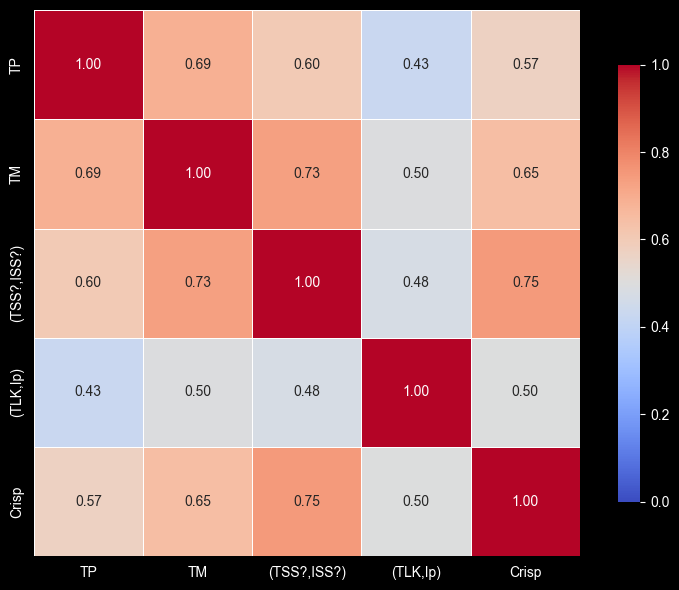

Directionality results saved to directionality_results.csv
OperatorLabel     Dataset  SelectedDirectedRules  SelectedUndirectedPairs  UnidirectionalPairs  BidirectionalPairs  DirectionalityRate
           TP    iris.csv                     28                       15                    2                  13            0.133333
           TP    wdbc.csv                     60                       37                   14                  23            0.378378
           TP vehicle.csv                    184                      100                   16                  84            0.160000
           TP abalone.csv                     99                       57                   15                  42            0.263158
           TP   magic.csv                     42                       24                    6                  18            0.250000
           TM    iris.csv                     30                       16                    2                  14            0.125

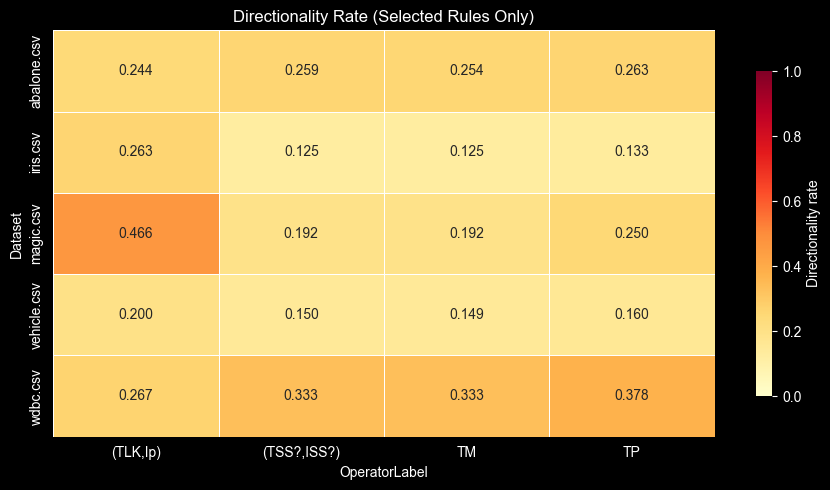

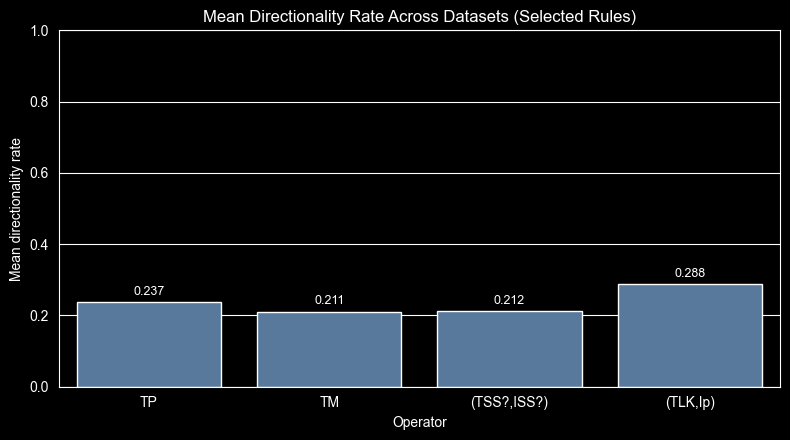

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Pairwise Jaccard matrix (existing experiment) ---
labels = ["TP", "TM", "(TSS?,ISS?)", "(TLK,Ip)", "Crisp"]

M = np.asarray(M, dtype=float)
M_up = np.triu(M)
M_sym = M_up + M_up.T - np.diag(np.diag(M_up))
np.fill_diagonal(M_sym, 1.0)

df_full = pd.DataFrame(M_sym, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_full,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
)
plt.tight_layout()
plt.show()


# --- Directionality-rate experiment (selected rules only) ---
# For each selected singleton rule A->C, verify if C->A is also selected.
# Directionality rate = (# unidirectional selected undirected pairs) / (# selected undirected pairs).

def _selected_directionality_stats(rule_list):
    directed = set()

    for r in rule_list:
        lr = getattr(r, 'lrule', None)
        if lr is None or len(lr) != 2:
            continue  # singleton antecedent only

        a = tuple(lr[0])
        c = tuple(lr[1])
        if a == c:
            continue

        directed.add((a, c))

    unidirectional = 0
    bidirectional = 0
    seen = set()

    for a, c in directed:
        undirected = tuple(sorted((a, c)))
        if undirected in seen:
            continue

        if (c, a) in directed:
            bidirectional += 1
        else:
            unidirectional += 1

        seen.add(undirected)

    selected_undirected_pairs = unidirectional + bidirectional
    directionality_rate = (float(unidirectional / selected_undirected_pairs)
                           if selected_undirected_pairs else np.nan)

    return {
        'SelectedDirectedRules': len(directed),
        'SelectedUndirectedPairs': selected_undirected_pairs,
        'UnidirectionalPairs': unidirectional,
        'BidirectionalPairs': bidirectional,
        'DirectionalityRate': directionality_rate,
    }


op_labels = labels[:n_operators]
rows = []

for idx_op in range(n_operators):
    for idx_dat, name_dataset in enumerate(datasets):
        stats = _selected_directionality_stats(results[idx_op][idx_dat])

        rows.append({
            'Operator': f'OP{idx_op}',
            'OperatorLabel': op_labels[idx_op] if idx_op < len(op_labels) else f'OP{idx_op}',
            'Dataset': name_dataset,
            'SelectedDirectedRules': stats['SelectedDirectedRules'],
            'SelectedUndirectedPairs': stats['SelectedUndirectedPairs'],
            'UnidirectionalPairs': stats['UnidirectionalPairs'],
            'BidirectionalPairs': stats['BidirectionalPairs'],
            'DirectionalityRate': stats['DirectionalityRate'],
        })


df_dir = pd.DataFrame(rows)
df_dir.to_csv('directionality_results.csv', index=False)

print('Directionality results saved to directionality_results.csv')
print(df_dir[['OperatorLabel', 'Dataset', 'SelectedDirectedRules', 'SelectedUndirectedPairs', 'UnidirectionalPairs', 'BidirectionalPairs', 'DirectionalityRate']].to_string(index=False))

print('Mean directionality rate by operator:')
print(df_dir.groupby('OperatorLabel', as_index=True)['DirectionalityRate'].mean().to_string())


# Plot 1: per-dataset directionality heatmap
pivot_dir = df_dir.pivot(index='Dataset', columns='OperatorLabel', values='DirectionalityRate')
plt.figure(figsize=(9, 5))
sns.heatmap(
    pivot_dir,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Directionality rate'},
)
plt.title('Directionality Rate (Selected Rules Only)')
plt.tight_layout()
plt.show()


# Plot 2: mean directionality by operator
df_mean = df_dir.groupby('OperatorLabel', as_index=False)['DirectionalityRate'].mean()
order = op_labels
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=df_mean, x='OperatorLabel', y='DirectionalityRate', order=order, color='#4C78A8')
ax.set_ylim(0, 1)
ax.set_xlabel('Operator')
ax.set_ylabel('Mean directionality rate')
ax.set_title('Mean Directionality Rate Across Datasets (Selected Rules)')
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.3f}', (p.get_x() + p.get_width() / 2, h), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

